# Stock Clustering Activity

In this notebook, we will:
- Use stock data
- Compute returns and other features
- Perform clustering using K-Means
- Visualize clusters using PCA


In [48]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
#Load Data
df=pd.read_csv('stock_data.csv')
df.drop('Date', axis=1, inplace=True)
df.head()

,AAPL,AMZN,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
0,123.470604,85.820000,164.890137,126.709869,124.154861,234.808945,14.303279,108.099998,97.812393
1,124.744125,85.139999,166.685303,127.891411,126.772530,224.537659,14.736924,113.639999,98.097061
2,123.421242,83.120003,165.454559,127.863106,126.344528,217.882843,14.253323,110.339996,100.291893
3,127.962456,86.080002,166.796356,130.309799,129.410110,220.450653,14.846834,113.059998,101.504105
4,128.485641,87.360001,162.474945,129.771332,128.862671,222.597046,15.615204,119.769997,99.612328


In [50]:
# Calculate daily returns
returns = df.pct_change().dropna()
returns.head()

,AAPL,AMZN,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
1,0.010314,-0.007924,0.010887,0.009325,0.021084,-0.043743,0.030318,0.051249,0.002910
2,-0.010605,-0.023726,-0.007384,-0.000221,-0.003376,-0.029638,-0.032816,-0.029039,0.022374
3,0.036794,0.035611,0.008110,0.019135,0.024264,0.011785,0.041640,0.024651,0.012087
4,0.004089,0.014870,-0.025908,-0.004132,-0.004230,0.009736,0.051753,0.059349,-0.018637
5,0.004457,0.028732,-0.002392,0.008954,0.027188,0.007617,0.017981,-0.007681,0.014935


In [51]:
# Compute mean return and volatility as features
features = pd.DataFrame({
    'mean_return': returns.mean(),
    'volatility': returns.std(),
})
features.head(10)

,mean_return,volatility
AAPL,0.001835,0.012570
AMZN,0.002511,0.020805
JNJ,-0.000341,0.010427
JPM,0.001128,0.013088
META,0.004493,0.025090
MSFT,0.001972,0.015824
NVDA,0.005442,0.030525
TSLA,0.003893,0.033166
XOM,0.000003,0.015677


In [52]:
# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [53]:
# Apply PCA for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features['cluster'] = clusters

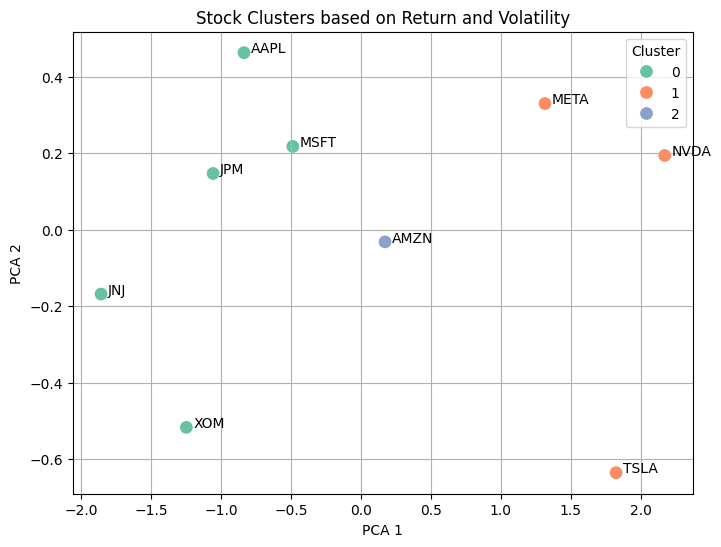

In [54]:
# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=clusters, s=100, palette='Set2')
for i, label in enumerate(features.index):
    plt.text(pca_components[i, 0]+0.05, pca_components[i, 1], label)
plt.title('Stock Clusters based on Return and Volatility')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [55]:
# View clustered tickers
for i in range(3):
    print(f"Cluster {i}:", features[features['cluster'] == i].index.tolist())

Cluster 0: ['AAPL', 'JNJ', 'JPM', 'MSFT', 'XOM']
Cluster 1: ['META', 'NVDA', 'TSLA']
Cluster 2: ['AMZN']


###Interpretation


1.   Cluster 0: Stable and Diversified Giants

*   Tickers: AAPL (Tech), JNJ (Healthcare), JPM (Finance), MSFT (Tech), XOM (Energy)
*   These stocks tend to have moderate returns and lower volatility.
*   Represents blue-chip, less volatile, and diversified sector leaders.

*   These firms often have strong fundamentals, consistent earnings, and lower risk — appealing to long-term and institutional investors.



2.   Cluster 1: High Growth, High Risk

*   Tickers: META (Tech), NVDA (Tech), TSLA (Auto/Tech)
*   This group likely showed higher average returns but with high volatility.
*   They are seen as innovative, fast-growing, and sensitive to market sentiment.
*   Suitable for growth-oriented portfolios or risk-tolerant investors.


📌3.   Cluster 2: AMZN as an Outlier

*   Ticker: AMZN (E-commerce/Cloud)
*   Amazon stands alone — this suggests its return-volatility profile is quite different from both clusters above.
*   When clustering separates a single point, it often means it's statistically distant from all others in the chosen feature space.

## Determine Optimal Clusters using Ward's Method (Hierarchical Clustering)

We use Ward's linkage and dendrogram to visually inspect the best number of clusters.

In [56]:
# Import necessary libraries for hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [57]:
# Compute linkage matrix using Ward's method
linkage_matrix = linkage(scaled_features, method='ward')

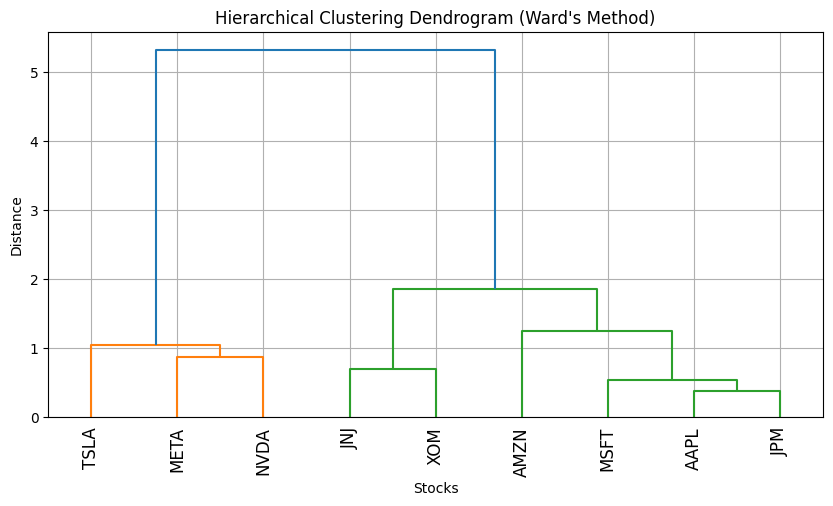

In [58]:
# Plot dendrogram to visualize cluster distances
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=features.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)")
plt.xlabel("Stocks")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [59]:
# Optional: Assign clusters based on dendrogram cut-off (e.g., 2 clusters)
cluster_labels = fcluster(linkage_matrix, t=2, criterion='maxclust')
features['ward_cluster'] = cluster_labels
features

,mean_return,volatility,cluster,ward_cluster
AAPL,0.001835,0.012570,0,2
AMZN,0.002511,0.020805,2,2
JNJ,-0.000341,0.010427,0,2
JPM,0.001128,0.013088,0,2
META,0.004493,0.025090,1,1
MSFT,0.001972,0.015824,0,2
NVDA,0.005442,0.030525,1,1
TSLA,0.003893,0.033166,1,1
XOM,0.000003,0.015677,0,2


<ipython-input-60-1187292521>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(features['PCA1'][i] + 0.01, features['PCA2'][i], features.index[i], fontsize=9)


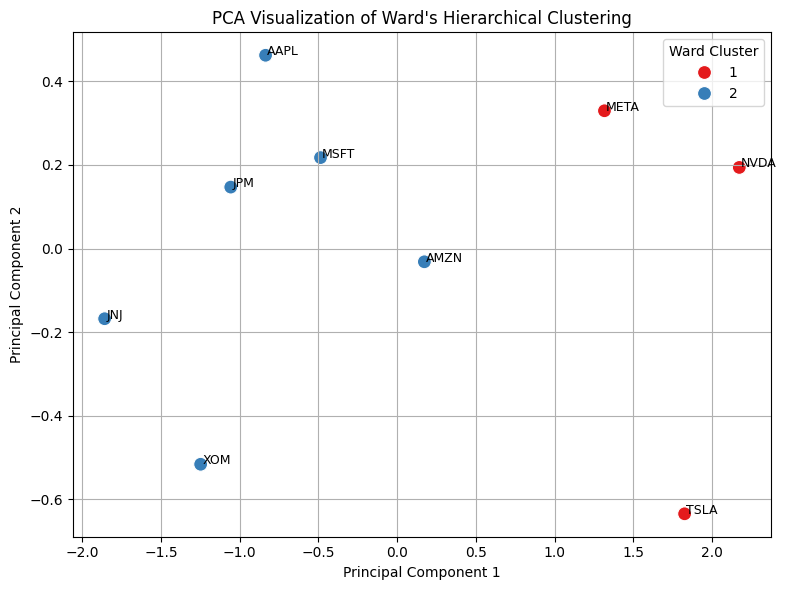

In [60]:
features['PCA1'] = pca_components[:, 0]
features['PCA2'] = pca_components[:, 1]
# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=features, x=pca_components[:, 0], y=pca_components[:, 1], hue=features['ward_cluster'], s=100, palette='Set1')
for i in range(len(features)):
    plt.text(features['PCA1'][i] + 0.01, features['PCA2'][i], features.index[i], fontsize=9)
plt.title("PCA Visualization of Ward's Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Ward Cluster")
plt.tight_layout()
plt.show()

### Ward’s method (using hierarchical clustering) grouped the stocks into:




   

1.   Cluster 1 (High-growth, High-volatility Tech)

*   META, NVDA, TSLA
*   High returns (≈0.0045–0.0054) and high volatility (0.025–0.033)




2.   Cluster 2 (Stable/Moderate)

*   AAPL, AMZN, JNJ, JPM, MSFT, XOM
*   Lower returns and lower volatility, though AMZN is somewhat higher



###📌 AMZN was included in this cluster likely because:



*   Its volatility (0.0208) is lower than META/NVDA/TSLA
*   It’s closer in behavior to AAPL or MSFT than to speculative growth stocks




